# Chapter 5, Example 1: Gauge transformations preserve a normal-factor-graph partition function

A gauge transformation changes the local tensors of a normal factor graph while preserving their complete contraction. This notebook verifies the identity on a binary three-cycle.

For every undirected edge $e$, choose two matrices $G_{e\to a}$ and $G_{e\to b}$ satisfying

$$
G_{e\to a}^{\mathsf T}G_{e\to b}=I.
$$

Each endpoint tensor is transformed along its incident edge indices. When the transformed tensors are contracted, the paired matrices collapse to the identity. The transformed local factors need not remain probability tables; the invariant object is the global partition function.

In [1]:
from pathlib import Path
import math
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

CWD = Path.cwd()
if CWD.name == "ch05":
    NOTEBOOK_DIR = CWD
elif (CWD / "notebooks" / "ch05").exists():
    NOTEBOOK_DIR = CWD / "notebooks" / "ch05"
else:
    NOTEBOOK_DIR = CWD
FIG_DIR = NOTEBOOK_DIR / "figs"
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "font.size": 15,
    "axes.titlesize": 17,
    "axes.labelsize": 15,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
    "figure.titlesize": 18,
})

NODE_COLOR = "#3f4c6b"
SECONDARY_NODE_COLOR = "#5b6784"
PINNED_NODE_COLOR = "#7b3f4c"


def save_figure(fig, stem):
    for suffix, kwargs in [("pdf", {}), ("png", {"dpi": 240})]:
        path = FIG_DIR / f"{stem}.{suffix}"
        fig.savefig(path, bbox_inches="tight", **kwargs)
        print(f"Saved: {path}")


def annotate_heatmap(ax, matrix, image, fmt=".2f"):
    norm = image.norm
    cmap = image.cmap
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            rgba = cmap(norm(matrix[i, j]))
            luminance = 0.2126 * rgba[0] + 0.7152 * rgba[1] + 0.0722 * rgba[2]
            color = "black" if luminance > 0.58 else "white"
            ax.text(j, i, format(matrix[i, j], fmt), ha="center", va="center", color=color, fontsize=13)


## Model and exact contraction

The normal factor graph is a triangle of factor nodes. Its three binary edge variables are $x_{01}$, $x_{12}$, and $x_{20}$. The partition function is

$$
Z=\sum_{x_{01},x_{12},x_{20}}
f_0(x_{20},x_{01})f_1(x_{01},x_{12})f_2(x_{12},x_{20}).
$$

In [2]:
factors = {
    0: np.array([[1.40, 0.65], [0.55, 1.15]]),
    1: np.array([[1.05, 0.72], [0.48, 1.38]]),
    2: np.array([[1.25, 0.58], [0.82, 1.10]]),
}

def triangle_partition(local_factors):
    total = 0.0
    for x01, x12, x20 in product(range(2), repeat=3):
        total += (local_factors[0][x20, x01]
                  * local_factors[1][x01, x12]
                  * local_factors[2][x12, x20])
    return total

Z_original = triangle_partition(factors)
print(f"Original partition function: {Z_original:.12f}")

Original partition function: 6.626010000000


## Paired gauge matrices

For each edge, the matrix at the second endpoint is selected as the inverse transpose of the matrix at the first endpoint. The matrices below also have nonnegative first rows at both endpoints, which will later allow us to form normalized probe beliefs.

In [3]:
edge_matrices = {}
parameters = {
    "01": (0.22, 0.31),
    "12": (0.16, 0.27),
    "20": (0.28, 0.19),
}
for edge, (a, b) in parameters.items():
    A = np.array([[1.0, a], [-b, 1.0]])
    B = np.linalg.inv(A).T
    edge_matrices[edge] = (A, B)
    assert np.allclose(A.T @ B, np.eye(2))
    assert np.all(A[0] >= 0) and np.all(B[0] >= 0)
    print(edge, "max skew-orthogonality error =", np.max(np.abs(A.T @ B - np.eye(2))))

01 max skew-orthogonality error = 2.567689554705532e-17
12 max skew-orthogonality error = 2.220446049250313e-16
20 max skew-orthogonality error = 2.220446049250313e-16


## Transform every local factor

The orientation convention is $0\to1$ on edge $01$, $1\to2$ on edge $12$, and $2\to0$ on edge $20$. The first matrix in each pair acts at the tail and the inverse-transpose matrix acts at the head.

In [4]:
G01_0, G01_1 = edge_matrices["01"]
G12_1, G12_2 = edge_matrices["12"]
G20_2, G20_0 = edge_matrices["20"]

transformed = {
    0: np.einsum("ia,jb,ab->ij", G20_0, G01_0, factors[0]),
    1: np.einsum("ia,jb,ab->ij", G01_1, G12_1, factors[1]),
    2: np.einsum("ia,jb,ab->ij", G12_2, G20_2, factors[2]),
}
Z_transformed = triangle_partition(transformed)
print(f"Transformed partition function: {Z_transformed:.12f}")
print(f"Absolute difference: {abs(Z_original-Z_transformed):.3e}")
assert np.allclose(Z_original, Z_transformed, atol=1e-12)

Transformed partition function: 6.626010000000
Absolute difference: 8.882e-16


## Figure: a local basis change on every edge

The two directed labels on each edge denote the paired matrices. Internal node labels are white so the graph remains legible when printed at reduced size.

Saved: figs/ch05_01_gauge_architecture.pdf
Saved: figs/ch05_01_gauge_architecture.png


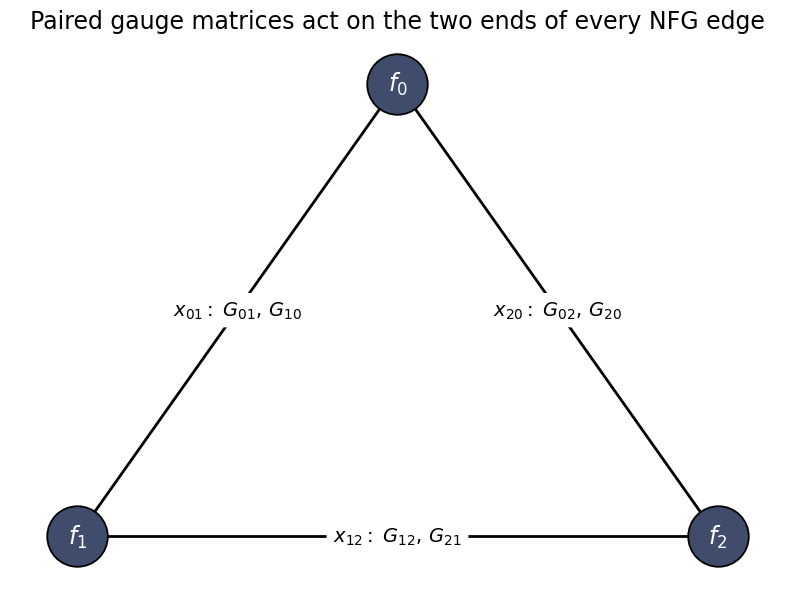

In [5]:
G = nx.Graph()
G.add_nodes_from([0, 1, 2])
G.add_edges_from([(0, 1), (1, 2), (2, 0)])
pos = {0: (0.0, 1.5), 1: (-1.5, -0.8), 2: (1.5, -0.8)}

fig, ax = plt.subplots(figsize=(8.2, 6.2))
nx.draw_networkx_nodes(G, pos, node_size=1900, node_color=NODE_COLOR, edgecolors="black", linewidths=1.3, ax=ax)
nx.draw_networkx_labels(G, pos, labels={i: rf"$f_{i}$" for i in G.nodes()}, font_color="white", font_size=17, ax=ax)
nx.draw_networkx_edges(G, pos, width=2.0, ax=ax)
edge_labels = {(0,1): r"$x_{01}:\;G_{01},\,G_{10}$", (1,2): r"$x_{12}:\;G_{12},\,G_{21}$", (0,2): r"$x_{20}:\;G_{02},\,G_{20}$"}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=14, rotate=False, label_pos=0.5, ax=ax)
ax.set_title("Paired gauge matrices act on the two ends of every NFG edge")
ax.axis("off")
fig.tight_layout()
save_figure(fig, "ch05_01_gauge_architecture")
plt.show()

## Figure: local factors change, the contraction does not

The transformed factors can contain negative entries even though the original factors are positive. This is not a contradiction: a general gauge transformation preserves the total contraction, not the interpretation of each transformed factor as a probability table.

Saved: figs/ch05_01_local_factor_transformation.pdf


Saved: figs/ch05_01_local_factor_transformation.png


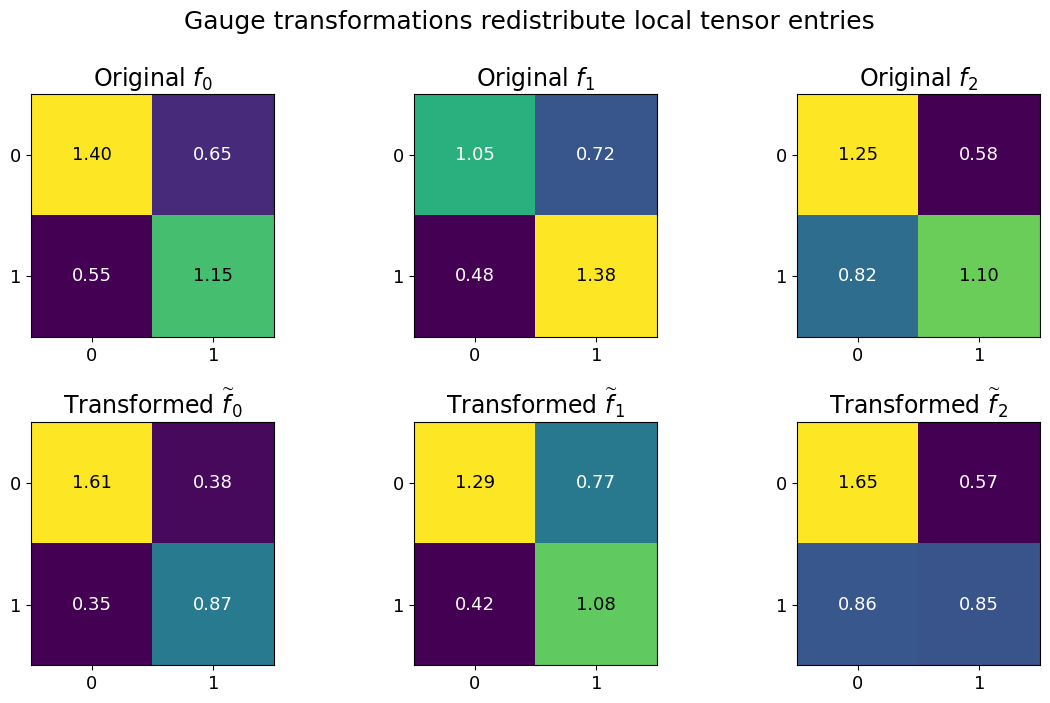

Saved: figs/ch05_01_partition_invariance.pdf
Saved: figs/ch05_01_partition_invariance.png


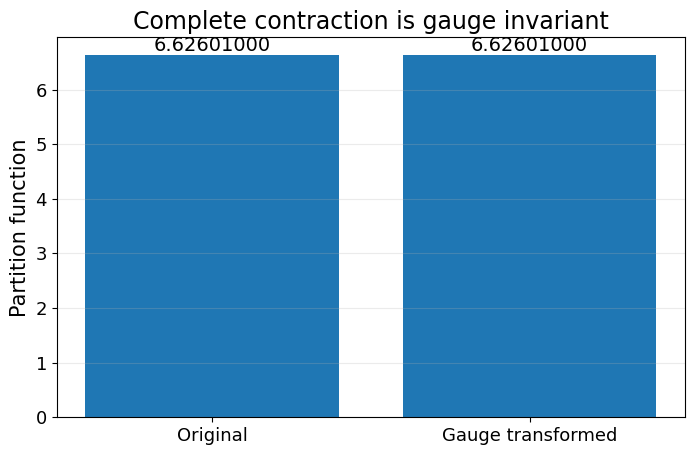

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(11.8, 7.2))
for column, node in enumerate([0, 1, 2]):
    image0 = axes[0, column].imshow(factors[node])
    annotate_heatmap(axes[0, column], factors[node], image0)
    axes[0, column].set_title(rf"Original $f_{node}$")
    image1 = axes[1, column].imshow(transformed[node])
    annotate_heatmap(axes[1, column], transformed[node], image1)
    axes[1, column].set_title(rf"Transformed $\widetilde f_{node}$")
    for ax in axes[:, column]:
        ax.set_xticks([0,1])
        ax.set_yticks([0,1])
fig.suptitle("Gauge transformations redistribute local tensor entries")
fig.tight_layout()
save_figure(fig, "ch05_01_local_factor_transformation")
plt.show()

fig, ax = plt.subplots(figsize=(7.2, 4.8))
values = [Z_original, Z_transformed]
bars = ax.bar(["Original", "Gauge transformed"], values)
ax.set_ylabel("Partition function")
ax.set_title("Complete contraction is gauge invariant")
ax.grid(axis="y", alpha=0.25)
for bar, value in zip(bars, values):
    ax.text(bar.get_x()+bar.get_width()/2, value, f"{value:.8f}", ha="center", va="bottom", fontsize=14)
fig.tight_layout()
save_figure(fig, "ch05_01_partition_invariance")
plt.show()

## Probe beliefs from the ground-state rows

Selecting row $0$ of every directed gauge matrix produces normalized edge beliefs. Combining these rows with the original factor produces normalized node beliefs. A generic gauge does not make these beliefs marginally consistent.

In [7]:
incidence = {
    0: [(G20_0, 0), (G01_0, 1)],
    1: [(G01_1, 0), (G12_1, 1)],
    2: [(G12_2, 0), (G20_2, 1)],
}
node_beliefs = {}
for node in [0,1,2]:
    b = factors[node].copy()
    b *= incidence[node][0][0][0, :, None]
    b *= incidence[node][1][0][0, None, :]
    b /= b.sum()
    node_beliefs[node] = b

edge_beliefs = {
    "01": G01_0[0] * G01_1[0],
    "12": G12_1[0] * G12_2[0],
    "20": G20_2[0] * G20_0[0],
}
for key in edge_beliefs:
    edge_beliefs[key] /= edge_beliefs[key].sum()

residuals = {
    "0--01": np.max(np.abs(node_beliefs[0].sum(axis=0)-edge_beliefs["01"])),
    "1--01": np.max(np.abs(node_beliefs[1].sum(axis=1)-edge_beliefs["01"])),
    "1--12": np.max(np.abs(node_beliefs[1].sum(axis=0)-edge_beliefs["12"])),
    "2--12": np.max(np.abs(node_beliefs[2].sum(axis=1)-edge_beliefs["12"])),
    "2--20": np.max(np.abs(node_beliefs[2].sum(axis=0)-edge_beliefs["20"])),
    "0--20": np.max(np.abs(node_beliefs[0].sum(axis=1)-edge_beliefs["20"])),
}
display(pd.Series(residuals, name="maximum marginal inconsistency").to_frame())

,maximum marginal inconsistency
0--01,0.048842
1--01,0.093302
1--12,0.091432
2--12,0.135972
2--20,0.092507
0--20,0.039469


## Exercises

1. Replace one matrix $A$ by a singular matrix and explain exactly where the invariance proof fails.
2. Use orthogonal matrices. Compare the signs and magnitudes of the transformed factors with the nonorthogonal example.
3. Search numerically for gauge matrices that reduce the variance of the transformed factor entries while preserving $Z$.
4. Verify the invariance on a four-node normal factor graph with one node of degree three.